#  Outlier Management — Detection & Treatment
### IFRI Mini ML Library · Technical Documentation
---
> **Authors:** Group 1 (Outlier Management)  
> **Library:** `ifri_mini_ml_lib`  
> **Language:** Python 3.x

---
## Table of Contents
1. [Introduction & Core Concepts](#1-introduction--core-concepts)
2. [Detection Methods](#2-detection-methods)
3. [Treatment Methods — Univariate](#3-treatment-methods--univariate)
4. [Treatment Methods — Multivariate](#4-treatment-methods--multivariate)
5. [ifri_mini_ml_lib vs Scikit-learn](#5-benchmark-vs-scikit-learn)
6. [Sources & References](#6-sources--references)

---
## 1. Introduction & Core Concepts

### What is an Outlier?

An **outlier** is a data point that deviates significantly from the rest of the dataset — it does not follow the same statistical pattern as the majority of observations.

> *"An outlier is an observation that lies an abnormal distance from other values in a random sample from a population."* — John Tukey, 1977

### Why Outliers Matter

| Impact | Description |
|--------|-------------|
| **Model degradation** | Most ML algorithms (linear regression, k-means…) are sensitive to extreme values |
| **Biased statistics** | Mean and standard deviation are pulled toward extreme values |
| **Signal vs. Noise** | Some outliers carry useful information (fraud, medical anomaly) |
| **Data quality** | Outliers often reveal data entry errors or sensor failures |

### Two Types of Outliers

```
UNIVARIATE   → Extreme value in a SINGLE feature
               Example: age = 200 in a human dataset

MULTIVARIATE → Abnormal COMBINATION of features
               Example: height=150cm + weight=120kg (each OK alone)
```

### Our Pipeline

```
Raw Data  ──►  Detection  ──►  Decision  ──►  Treatment  ──►  Clean Data
               (IQR, Z-Score,   (is it an     (remove,
               IF, LOF)          outlier?)      impute, cap…)
```

- **Detection** → identifies which points are outliers (returns `0/1` labels)
- **Treatment** → decides what to do with detected outliers

All detectors share a unified interface:

```python
detector = OutlierDetector(method="lof", n_neighbors=20, contamination=0.05)
detector.fit(X)
labels = detector.predict(X)   # 0 = normal, 1 = outlier
```

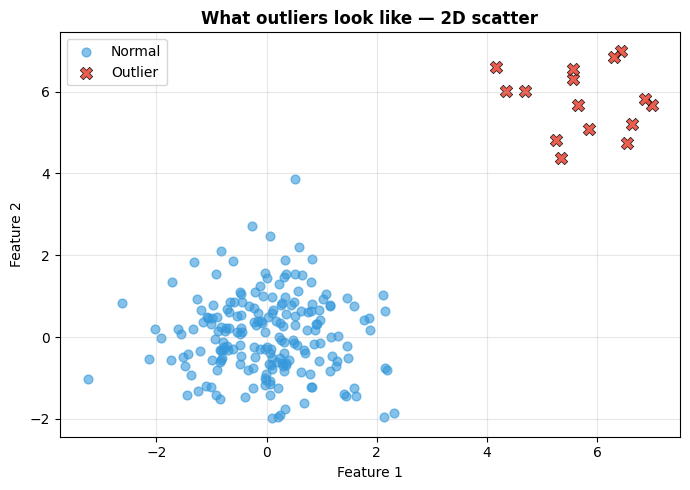

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n_normal, n_outliers = 200, 15
X_normal  = np.random.randn(n_normal, 2)
X_outlier = np.random.uniform(low=4, high=7, size=(n_outliers, 2))
X = np.vstack([X_normal, X_outlier])
y = np.array([0]*n_normal + [1]*n_outliers)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[y==0, 0], X[y==0, 1], c="#3498db", alpha=0.6, s=40, label="Normal")
ax.scatter(X[y==1, 0], X[y==1, 1], c="#e74c3c", alpha=0.9, s=80,
           marker="X", label="Outlier", edgecolors="black", linewidths=0.5)
ax.set_title("What outliers look like — 2D scatter", fontweight="bold")
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Detection Methods

> IQR, Z-Score, and Isolation Forest were implemented by **Group 4**.  
> **LOF** was implemented from scratch by our group.

---

### 2.1 IQR — Interquartile Range

**Principle:** defines *fences* beyond which a value is an outlier.

$$IQR = Q_3 - Q_1$$
$$\text{Lower fence} = Q_1 - k \times IQR \qquad \text{Upper fence} = Q_3 + k \times IQR$$

A point $x$ is an outlier if $x < \text{Lower fence}$ or $x > \text{Upper fence}$.  
Default $k = 1.5$ retains ~99.3% of normally distributed data. Use $k = 3.0$ for extreme outliers only.

| Property | Value |
|----------|-------|
| Complexity | O(n log n) |
| Distribution-free | Yes (non-parametric) |
| Multivariate | Feature by feature |
| Supervised | No |

**`detect_iqr(factor=1.5)`** — computes Q1, Q3, flags values outside the fences.

---

### 2.2 Z-Score

**Principle:** measures how many standard deviations a point is from the mean.

$$Z_i = \frac{x_i - \mu}{\sigma}$$

A point is an outlier if $|Z_i| > \text{threshold}$ (default: 3.0).  
⚠ **Sensitive to the mean and std** — both are themselves influenced by extreme values. Works best on near-Gaussian distributions.

**`detect_zscore(threshold=3.0)`** — standardizes the column, flags points beyond the threshold.

---

### 2.3 Isolation Forest

**Principle:** an outlier is *easier to isolate* than a normal point. Random trees partition the feature space; outliers are separated in fewer cuts.

$$s(x, \psi) = 2^{-\frac{E[h(x)]}{c(\psi)}}$$

| Score | Interpretation |
|-------|---------------|
| $s \approx 1$ | Isolated quickly → **outlier** |
| $s \approx 0.5$ | Hard to isolate → **normal** |

**`detect_isolation_forest(n_trees=100, contamination=0.05)`**

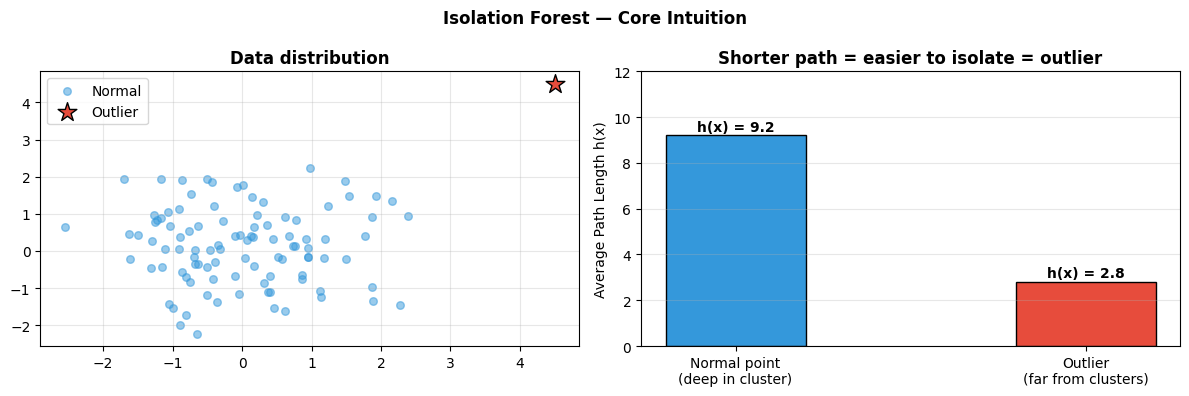

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Isolation Forest — Core Intuition", fontsize=12, fontweight="bold")

np.random.seed(0)
X_demo = np.random.randn(100, 2)
outlier_pt = np.array([[4.5, 4.5]])

ax1.scatter(X_demo[:,0], X_demo[:,1], c="#3498db", alpha=0.5, s=30, label="Normal")
ax1.scatter(*outlier_pt[0], c="#e74c3c", s=200, marker="*", zorder=5,
            label="Outlier", edgecolors="black")
ax1.set_title("Data distribution", fontweight="bold")
ax1.legend(); ax1.grid(alpha=0.3)

bars = ax2.bar(["Normal point\n(deep in cluster)", "Outlier\n(far from clusters)"],
               [9.2, 2.8], color=["#3498db", "#e74c3c"], width=0.4, edgecolor="black")
ax2.set_ylabel("Average Path Length h(x)")
ax2.set_title("Shorter path = easier to isolate = outlier", fontweight="bold")
ax2.set_ylim(0, 12)
for bar, val in zip(bars, [9.2, 2.8]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.2,
             f"h(x) = {val}", ha="center", fontweight="bold")
ax2.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---

### 2.4 LOF — Local Outlier Factor

**Principle:** Unlike IQR and Z-Score which use *global* statistics, LOF compares each point to its **local neighborhood**. A point in a sparse region surrounded by dense clusters is an outlier.

**① k-distance** — distance to the $k$-th nearest neighbor:  
$$k\text{-distance}(p) = d(p,\ k\text{-th neighbor})$$

**② Reachability distance** — smooths distances in very dense areas:  
$$\text{reach-dist}_k(p, o) = \max\left(k\text{-distance}(o),\ d(p, o)\right)$$

**③ Local Reachability Density:**  
$$\text{lrd}_k(p) = \frac{1}{\frac{1}{|N_k(p)|}\sum_{o \in N_k(p)} \text{reach-dist}_k(p, o)}$$

**④ LOF Score:**  
$$LOF_k(p) = \frac{\text{mean}\left(\text{lrd}(\text{neighbors of } p)\right)}{\text{lrd}(p)}$$

| LOF Score | Interpretation |
|-----------|---------------|
| $LOF \approx 1$ | Same density as neighbors → **normal** |
| $LOF \gg 1$ | Much less dense than neighbors → **outlier** |

| Function | Role |
|----------|------|
| `fit(X)` | Stores training data — LOF is a lazy learner, no computation here |
| `_k_neighbors(x, X)` | Returns the k nearest neighbors of `x`, their indices, and the k-distance |
| `_reach_dist(x, o, k_dist_o)` | Reachability distance from `x` to neighbor `o` |
| `_lrd(x, X)` | Local reachability density — inverse of mean reachability distance |
| `score_samples(X)` | LOF score per point — ratio of neighbor densities to point density |
| `predict(X)` | Returns `0` (normal) or `1` (outlier) using the contamination threshold |

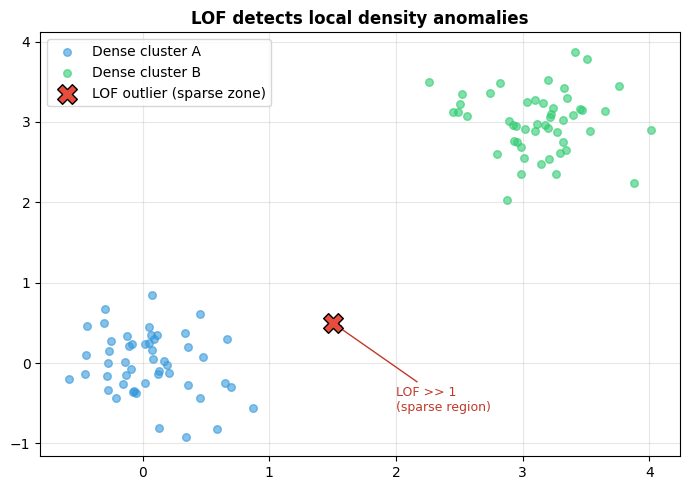

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
np.random.seed(1)
cluster_a = np.random.randn(50, 2) * 0.4 + [0, 0]
cluster_b = np.random.randn(50, 2) * 0.4 + [3, 3]
sparse_pt = np.array([[1.5, 0.5]])

ax.scatter(cluster_a[:,0], cluster_a[:,1], c="#3498db", s=30, alpha=0.6, label="Dense cluster A")
ax.scatter(cluster_b[:,0], cluster_b[:,1], c="#2ecc71", s=30, alpha=0.6, label="Dense cluster B")
ax.scatter(*sparse_pt[0], c="#e74c3c", s=200, marker="X", zorder=5,
           edgecolors="black", label="LOF outlier (sparse zone)")
ax.annotate("LOF >> 1\n(sparse region)", xy=sparse_pt[0], xytext=[2.0, -0.6],
            fontsize=9, color="#c0392b", arrowprops=dict(arrowstyle="->", color="#c0392b"))
ax.set_title("LOF detects local density anomalies", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Treatment Methods — Univariate

### What does "treating" an outlier mean?

Detection tells us *which* points are outliers. Treatment answers the question: **what do we do with them?**  
The answer depends on the context:

- Is it a **data entry error**? → Remove it or replace it with a sensible value.
- Is it a **rare but real event**? → Keep it, but reduce its influence (capping, transformation).
- Do we **need to keep all rows**? → Replace the value, never delete.

**Univariate treatment** handles each column **independently**, one at a time.  
It is appropriate when outliers were detected feature by feature (IQR, Z-Score).

| Method | Removes rows? | Modifies values? | Best when |
|--------|:---:|:---:|-----------|
| **Remove** | yes | no | Dataset large enough, clear data error |
| **Winsorize (Capping)** | no | yes | Must keep all rows |
| **Impute Median** | no | yes | Skewed distribution |
| **Impute Mean** | no | yes | Near-Gaussian distribution |
| **Log Transform** | no | yes | Right-skewed, positive values |
| **Sqrt Transform** | no | yes | Moderately skewed, softer than log |

---

### 3.1 Removal

**Concept:** The simplest possible treatment — delete the row entirely.

**When to use it:**
- The outlier is clearly a **data error** (age = 500, negative salary…)
- The dataset is **large enough** that losing a few rows won't hurt
- You are confident the outlier carries no useful information

**When NOT to use it:**
- Small dataset — every row counts
- The outlier might be a real and meaningful event (fraud detection, medical data)

```
Before: [22, 25, 27, 23, 24, 200]   ← age = 200, clearly an error
After:  [22, 25, 27, 23, 24]         ← the row is dropped
```

| Function | Role |
|----------|------|
| `remove_outliers(outlier_indices)` | Drops the rows at the given indices using `DataFrame.drop()`. Works on a copy — the original is never modified. |

---

### 3.2 Winsorizing (Capping)

**Concept:** Instead of deleting extreme values, we **clip** them to the nearest acceptable boundary.  
The row is kept — only the extreme value is replaced by the bound.

**Intuition:** Imagine you are grading exams on a 0–100 scale, but due to a bug some scores are 150 or -20. Winsorizing would cap them at 100 and 0 respectively — the student still has a row, but with a corrected value.

**Formula:**
$$x_i^* = \begin{cases} L & \text{if } x_i < L \\ U & \text{if } x_i > U \\ x_i & \text{otherwise} \end{cases}$$

where $L = Q_{\alpha}$ (lower quantile) and $U = Q_{1-\alpha}$ (upper quantile), with default $\alpha = 0.05$.

```
Column: [10, 12, 11, 13, 200]    upper bound at 95th percentile = 13.9
After:  [10, 12, 11, 13, 13.9]   ← 200 is pulled back to the bound
```

**Key point:** The bounds are computed from the data itself using quantiles — no manual threshold needed.

| Function | Role |
|----------|------|
| `winsorize(lower_quantile=0.05, upper_quantile=0.95)` | Iterates over each numeric column, computes its Q5 and Q95, then applies `pandas.Series.clip()` to bring values back within those bounds. |

---

### 3.3 Imputation by Median

**Concept:** Replace the outlier value with the **median** of the normal (inlier) values of that column.

**Why the median and not the mean?**  
The median is the middle value when all values are sorted. It is **robust to extreme values** — adding one very large number barely changes the median, but it can shift the mean dramatically.  
This makes it the preferred choice when the distribution is skewed.

**Why compute it on inliers only?**  
If we include the outliers themselves in the median computation, we are using a contaminated reference to fix the contamination — circular and biased.

$$x_i^* = \text{median}\left(\{x_j : j \notin \text{outlier\_indices}\}\right)$$

```
Column: [22, 25, 27, 23, 24, 200]
Inlier median: median([22, 25, 27, 23, 24]) = 24
After:  [22, 25, 27, 23, 24, 24]   ← 200 replaced by 24
```

| Function | Role |
|----------|------|
| `impute_median(outlier_indices)` | For each numeric column, computes the median on inlier rows only (using a boolean mask `~index.isin(outlier_indices)`), then replaces the outlier cells with that value. |

---

### 3.4 Imputation by Mean

**Concept:** Replace the outlier value with the **mean** of the inlier values of that column.

**When to prefer mean over median?**  
When the distribution is approximately symmetric (Gaussian-like), the mean and median are close to each other, and the mean is a slightly more precise estimate because it uses all values, not just the middle one.

$$x_i^* = \bar{x}_{\text{inliers}} = \frac{1}{n_{\text{inliers}}} \sum_{j \notin \text{outliers}} x_j$$

**Caution:** If several outliers remain undetected, they will bias the mean — and the imputed value will be unreliable. When in doubt, use the median.

| Function | Role |
|----------|------|
| `impute_mean(outlier_indices)` | Same logic as `impute_median`, but uses `.mean()` instead of `.median()` on the inlier rows. Also casts the column to `float` to safely accept the computed mean. |

---

### 3.5 Log Transform

**Concept:** Apply a logarithm to **compress** the scale of the column. Large values are brought closer to small values, without deleting anything.

**Intuition:** On a log scale, the gap between 10 and 100 is the same as the gap between 100 and 1000. A salary of 500,000 is no longer astronomically far from 30,000 — both fit comfortably on the same scale.

$$x_i^* = \log(1 + x_i)$$

We use $\log(1+x)$ instead of $\log(x)$ to handle zeros safely: $\log(1+0) = 0$, while $\log(0) = -\infty$.

```
Before: [10,   100,   1000,  10000,  100000]
After:  [2.4,  4.6,   6.9,   9.2,    11.5  ]   ← scale compressed dramatically
```

**When to use it:**
- Right-skewed data (income, prices, population counts)
- When you want to *reduce* the influence of extreme values without removing them

 Only applicable to **non-negative** columns — log is undefined for negative numbers.

| Function | Role |
|----------|------|
| `log_transform(columns=None)` | Applies `numpy.log1p()` (= $\log(1+x)$) to each target column. Skips any column that contains negative values and prints a warning. If `columns=None`, applies to all numeric columns. |

---

### 3.6 Square Root Transform

**Concept:** A softer version of the log transform. Instead of taking the logarithm, we take the square root — less aggressive compression.

$$x_i^* = \sqrt{x_i}$$

```
Before: [1,  4,   9,   100,  10000]
After:  [1,  2,   3,   10,   100  ]   ← extreme values reduced, but less than log
```

**Log vs Sqrt — how to choose?**

| | Log Transform | Sqrt Transform |
|-|:---:|:---:|
| Compression strength | Strong | Moderate |
| Good for | Highly skewed (e-commerce, salaries) | Moderately skewed (counts, scores) |
| Handles zeros? | yes (via log1p) | yes ($\sqrt{0} = 0$) |
| Handles negatives? | no | no |

| Function | Role |
|----------|------|
| `sqrt_transform(columns=None)` | Applies `numpy.sqrt()` to each target column. Skips columns with negative values. If `columns=None`, applies to all numeric columns. |

---

### 3.7 Unified Entry Point — `treat()`

All methods are accessible through a single dispatcher:

```python
ut = Univariate_Treatment(df)

df_clean = ut.treat("remove",        outlier_indices=[8, 42])
df_clean = ut.treat("winsorize",     lower_quantile=0.05, upper_quantile=0.95)
df_clean = ut.treat("impute_median", outlier_indices=[8, 42])
df_clean = ut.treat("impute_mean",   outlier_indices=[8, 42])
df_clean = ut.treat("log")
df_clean = ut.treat("sqrt")
```

The `treat()` method routes the call to the correct method based on the `method` string. It raises a clear `ValueError` if an unknown method name is passed.

Column 'value' → capped to [0.24, 17.51]
Column 'value' → outliers replaced by median = 2.86
Column 'value' → log(1+x) transformation applied


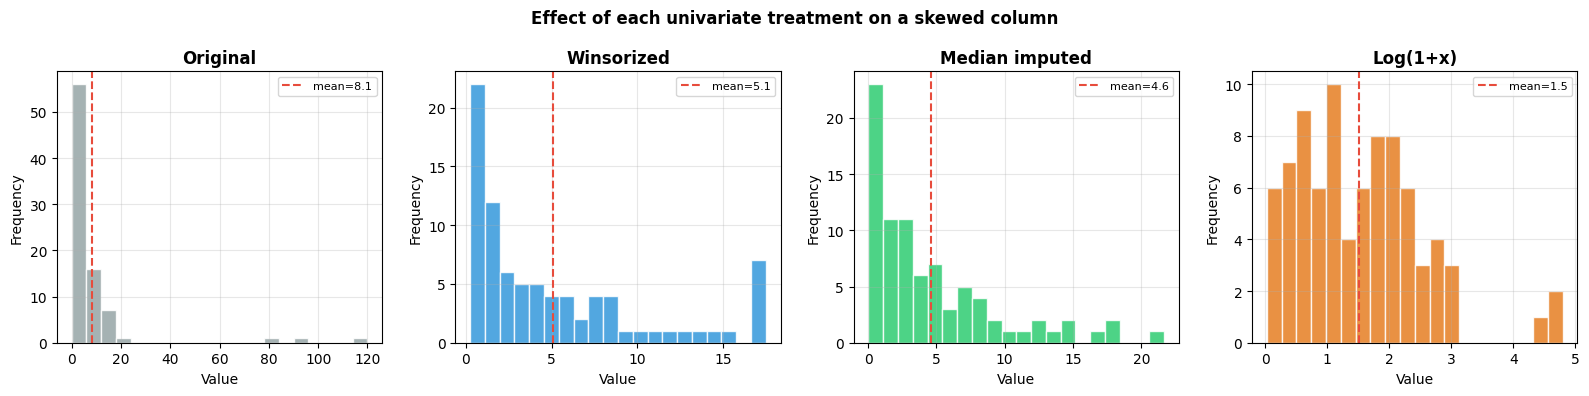

In [ ]:
# Visual comparison — effect of each univariate treatment on a skewed column

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from ifri_mini_ml_lib.preprocessing.outlier_management.Treatment.univariate_treatment import Univariate_Treatment

np.random.seed(42)
base = np.random.exponential(scale=5, size=80)     # right-skewed
outliers = np.array([80, 120, 95])                  # extreme values
column_data = np.concatenate([base, outliers])

df_demo = pd.DataFrame({"value": column_data})
outlier_idx = list(range(80, 83))
ut = Univariate_Treatment(df_demo)

versions = {
    "Original":       df_demo["value"].values,
    "Winsorized":     ut.treat("winsorize")["value"].values,
    "Median imputed": ut.treat("impute_median", outlier_indices=outlier_idx)["value"].values,
    "Log(1+x)": ut.treat("log")["value"].values,
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Effect of each univariate treatment on a skewed column",
             fontweight="bold", fontsize=12)

colors = ["#95a5a6", "#3498db", "#2ecc71", "#e67e22"]
for ax, (label, vals), color in zip(axes, versions.items(), colors):
    ax.hist(vals, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.axvline(np.mean(vals), color="#e74c3c", linestyle="--",
               linewidth=1.5, label=f"mean={np.mean(vals):.1f}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Treatment Methods — Multivariate

### Why a separate multivariate treatment?

Consider this example:

| height | weight | Label |
|--------|--------|-------|
| 175 cm | 70 kg  |  Normal |
| 150 cm | 120 kg |  Outlier |

Looking at each column alone: 150 cm is a normal height, 120 kg is a heavy but plausible weight.  
**Together**, the combination is anomalous — it falls outside the typical height/weight relationship.

Univariate treatment would miss this completely. **Multivariate treatment** considers **all features simultaneously** — it preserves the relationships between columns when replacing values.

| Method | Key idea |
|--------|----------|
| **Remove** | Drop the entire row |
| **Winsorize** | Cap each column independently but consistently |
| **Impute Median** | Replace all numeric columns of the row with inlier medians |
| **KNN Imputation** | Replace with a weighted average of k nearest inlier neighbors |

---

### 4.1 Multivariate Removal

**Concept:** Drop the entire row. Identical to univariate removal, but the *reason* for flagging is different — the row is anomalous because of an **unusual combination** of values across features, not a single extreme column.

```
Row 5: height=150, weight=120   → flagged by LOF or Isolation Forest
After: row 5 is deleted entirely
```

| Function | Role |
|----------|------|
| `remove_outliers(outlier_indices)` | Drops the specified rows using `DataFrame.drop()`. Returns a new DataFrame — original is untouched. |

---

### 4.2 Multivariate Winsorizing

**Concept:** Cap each column at its own quantile bounds — same formula as univariate winsorizing.  
The "multivariate" aspect means the capping is applied **consistently across all columns at once**, preserving the relative scale between features.

$$x_{i,j}^* = \text{clip}(x_{i,j},\ Q_\alpha^{(j)},\ Q_{1-\alpha}^{(j)}) \quad \forall j$$

| Function | Role |
|----------|------|
| `winsorize(lower_quantile=0.05, upper_quantile=0.95)` | Loops over all numeric columns, computes Q5/Q95 per column, clips values using `pandas.Series.clip()`. |

---

### 4.3 Multivariate Median Imputation

**Concept:** For each outlier row, replace **all its numeric columns** with the corresponding column medians — computed on inlier rows only.

**Why "all columns" at once?**  
Since the row was flagged as a multivariate outlier (anomalous combination), we cannot just fix one column — the whole row needs to be replaced with coherent, representative values.

$$x_{i,j}^* = \text{median}\left(\{x_{k,j} : k \notin \text{outliers}\}\right) \quad \forall j$$

```
Outlier row:   height=150, weight=120, age=32
Inlier medians:            height=172, weight=68, age=29
Imputed row:   height=172, weight=68,  age=29
```

| Function | Role |
|----------|------|
| `impute_median(outlier_indices)` | For each numeric column, computes the inlier median (boolean mask on index), then replaces outlier row values column by column. |

---

### 4.4 KNN Imputation *(Most Powerful)*

**Concept:** Instead of replacing an outlier row with generic column medians, we find the $k$ most **similar** normal rows in the dataset and compute a **weighted average** of their values.  
Closer neighbors contribute more than distant ones.

**Intuition:** If a patient's record is anomalous, we find the $k$ most similar *normal* patients (same age range, similar height, etc.) and use their average values to reconstruct the outlier's record — much smarter than just using the global median.

**Step-by-step algorithm:**

**Step 1 — Euclidean distance to all inliers**  
We measure how far the outlier point is from every normal point, using all features simultaneously:
$$d(p, q) = \sqrt{\sum_{j=1}^{d}(p_j - q_j)^2}$$

**Step 2 — Select the k nearest inliers**  
Sort all distances and keep the $k$ smallest. These are the "most similar" normal rows.

**Step 3 — Inverse-distance weights**  
Closer neighbors should contribute more. We use inverse distance as weight:
$$w_i = \frac{1}{d(p, q_i) + \varepsilon}, \qquad \tilde{w}_i = \frac{w_i}{\sum_j w_j}$$

The small $\varepsilon = 10^{-10}$ prevents division by zero if two points are identical.

**Step 4 — Weighted imputation per feature**  
For each column $j$, the imputed value is the weighted average of the $k$ neighbors' values:
$$x_{p,j}^* = \sum_{i=1}^{k} \tilde{w}_i \cdot x_{q_i, j}$$

```
Outlier: height=150, weight=120
3 nearest inlier neighbors:
  q1 (d=5.2):  height=168, weight=65  → weight=0.19 / 0.55 = 0.35
  q2 (d=6.1):  height=171, weight=70  → weight=0.16 / 0.55 = 0.30
  q3 (d=9.3):  height=165, weight=62  → weight=0.11 / 0.55 = 0.20  (approx)
Imputed height = 0.35×168 + 0.30×171 + 0.20×165 + … ≈ 168.5
```

| Function | Role |
|----------|------|
| `impute_knn(outlier_indices, n_neighbors=5)` | Main entry point — for each outlier row: computes distances to all inliers, selects k nearest, computes inverse-distance weights, imputes each column. |
| `_euclidean_distances(point, matrix)` | Helper — vectorized Euclidean distance from a single point to all rows of a matrix. Uses NumPy broadcasting: `matrix - point` subtracts the outlier from every row at once, avoiding a Python loop. |

**Why NumPy broadcasting matters here:**  
Without broadcasting, computing distances would require a loop over all inlier rows — very slow.  
Broadcasting lets NumPy subtract the 1D outlier point from every row of the inlier matrix in a single operation, making the computation fast even for large datasets.

---

### 4.5 Unified Entry Point — `treat()`

```python
mt = Multivariate_Treatment(df)

df_clean = mt.treat("remove",        outlier_indices=[5, 12])
df_clean = mt.treat("winsorize",     lower_quantile=0.05, upper_quantile=0.95)
df_clean = mt.treat("impute_median", outlier_indices=[5, 12])
df_clean = mt.treat("impute_knn",    outlier_indices=[5, 12], n_neighbors=5)
```

Row 60 → replaced using 3 nearest neighbors


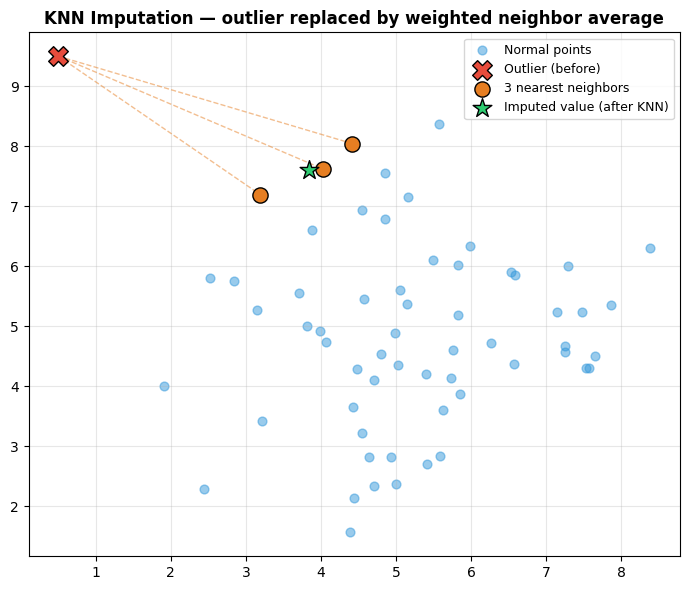

In [ ]:
# KNN imputation — visual intuition
# The outlier (red X) is replaced using its nearest normal neighbors (orange)
from ifri_mini_ml_lib.preprocessing.outlier_management.Treatment.multivariate_treatment import Multivariate_Treatment

np.random.seed(7)
inliers = np.random.randn(60, 2) * 1.5 + [5, 5]
outlier = np.array([[0.5, 9.5]])
all_pts = np.vstack([inliers, outlier])
outlier_global_idx = 60

df_knn = pd.DataFrame(all_pts, columns=["feature_1", "feature_2"])
mt = Multivariate_Treatment(df_knn)
df_imputed = mt.treat("impute_knn", outlier_indices=[outlier_global_idx], n_neighbors=3)

# Find the 3 nearest neighbors (for visualization)
dists = np.sqrt(((inliers - outlier)**2).sum(axis=1))
knn_idx = np.argsort(dists)[:3]
imputed_pt = df_imputed.loc[outlier_global_idx, ["feature_1", "feature_2"]].values

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(inliers[:,0], inliers[:,1], c="#3498db", s=40, alpha=0.5, label="Normal points")
ax.scatter(*outlier[0], c="#e74c3c", s=200, marker="X",
           edgecolors="black", zorder=5, label="Outlier (before)")
ax.scatter(inliers[knn_idx,0], inliers[knn_idx,1], c="#e67e22", s=120,
           edgecolors="black", zorder=4, label="3 nearest neighbors")
ax.scatter(*imputed_pt, c="#2ecc71", s=200, marker="*",
           edgecolors="black", zorder=6, label="Imputed value (after KNN)")
for ni in knn_idx:
    ax.plot([outlier[0,0], inliers[ni,0]], [outlier[0,1], inliers[ni,1]],
            "--", color="#e67e22", alpha=0.5, linewidth=1)
ax.set_title("KNN Imputation — outlier replaced by weighted neighbor average",
             fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. ifri_mini_ml_lib vs Scikit-learn — Treatment Comparison

On this benchmark we focus on **treatment quality and speed**, not detection.  
Outliers are injected synthetically so their positions are exactly known — no detector needed.

We compare our treatment implementations against scikit-learn's equivalents on the same data:

| Our implementation | Scikit-learn equivalent |
|--------------------|------------------------|
| `Univariate_Treatment.winsorize()` | Manual clip with `numpy` (no direct sklearn equiv) |
| `Univariate_Treatment.impute_median()` | `sklearn.impute.SimpleImputer(strategy="median")` |
| `Univariate_Treatment.impute_mean()` | `sklearn.impute.SimpleImputer(strategy="mean")` |
| `Univariate_Treatment.log_transform()` | `sklearn.preprocessing.FunctionTransformer(np.log1p)` |
| `Multivariate_Treatment.impute_knn()` | `sklearn.impute.KNNImputer(n_neighbors=5)` |

### What we measure

| Metric | Description |
|--------|-------------|
| **Time (ms)** | Execution time, average of 5 runs |
| **MSE on outlier rows** | Mean Squared Error between imputed values and the original clean values — lower is better |
| **Column mean shift** | How much the column mean changed after treatment — smaller shift = less distortion |

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer

from ifri_mini_ml_lib.preprocessing.outlier_management.Treatment.univariate_treatment import Univariate_Treatment
from ifri_mini_ml_lib.preprocessing.outlier_management.Treatment.multivariate_treatment import Multivariate_Treatment

np.random.seed(42)

# ── Dataset generation ────────────────────────────────────────────────────
# We build a clean dataset first, then inject known outliers at fixed indices.
# This lets us measure how well each method restores the original values.

N_NORMAL   = 500
N_OUTLIERS = 30
N_FEATURES = 4
OUTLIER_IDX = list(range(N_NORMAL, N_NORMAL + N_OUTLIERS))  # last 30 rows

# Clean data — Gaussian, realistic scale
X_clean = np.column_stack([
    np.random.normal(170, 10, N_NORMAL + N_OUTLIERS),   # height (cm)
    np.random.normal(70,   8, N_NORMAL + N_OUTLIERS),   # weight (kg)
    np.random.normal(35,   5, N_NORMAL + N_OUTLIERS),   # age
    np.random.normal(50000, 8000, N_NORMAL + N_OUTLIERS) # salary
])

# Save the "true" clean values for outlier rows (our ground truth for MSE)
X_ground_truth = X_clean[OUTLIER_IDX].copy()

# Inject outliers — extreme values at known positions
X_dirty = X_clean.copy()
X_dirty[OUTLIER_IDX, 0] = np.random.uniform(220, 260, N_OUTLIERS)    # height anomaly
X_dirty[OUTLIER_IDX, 1] = np.random.uniform(150, 200, N_OUTLIERS)    # weight anomaly
X_dirty[OUTLIER_IDX, 2] = np.random.uniform(120, 150, N_OUTLIERS)    # age anomaly
X_dirty[OUTLIER_IDX, 3] = np.random.uniform(500000, 900000, N_OUTLIERS) # salary anomaly

df_dirty = pd.DataFrame(X_dirty, columns=["height", "weight", "age", "salary"])

print(f"Dataset: {N_NORMAL} normal rows + {N_OUTLIERS} injected outliers")
print(f"Outlier indices: {OUTLIER_IDX[0]} → {OUTLIER_IDX[-1]}")
print(f"\nSample outlier row:\n{df_dirty.iloc[OUTLIER_IDX[0]]}")

# ── ifri_mini_ml_lib helpers ─────────────────────────────────────────────────────

def mse_on_outliers(df_treated, ground_truth, outlier_idx):
    """MSE between treated values and original clean values on outlier rows only."""
    treated_vals = df_treated.iloc[outlier_idx].values
    return round(float(np.mean((treated_vals - ground_truth) ** 2)), 2)

def mean_shift(df_original, df_treated):
    """Average absolute change in column means — measures global data distortion."""
    shift = np.abs(df_original.mean() - df_treated.mean()).mean()
    return round(float(shift), 4)

def run_treatment(name, fn, n_runs=5):
    """Runs fn() n_runs times, returns avg time + quality metrics."""
    times, result = [], None
    for _ in range(n_runs):
        t0 = time.perf_counter()
        result = fn()
        times.append(time.perf_counter() - t0)
    return {
        "method": name,
        "time_ms":    round(np.mean(times) * 1000, 2),
        "mse_outliers": mse_on_outliers(result, X_ground_truth, OUTLIER_IDX),
        "mean_shift":   mean_shift(df_dirty, result),
    }

print("\nHelpers ready.")

Dataset: 500 normal rows + 30 injected outliers
Outlier indices: 500 → 529

Sample outlier row:
height       241.237507
weight       194.928030
age          131.644971
salary    519991.611464
Name: 500, dtype: float64

Helpers ready.


In [6]:
results = []

# ── Median imputation ─────────────────────────────────────────────────────
results.append(run_treatment(
    "[OURS]    Univariate median",
    lambda: Univariate_Treatment(df_dirty).treat("impute_median", outlier_indices=OUTLIER_IDX)
))

sk_median = SimpleImputer(strategy="median")
# sklearn imputes NaN — we temporarily mask outlier rows with NaN for fair comparison
def sklearn_median():
    df_nan = df_dirty.copy()
    df_nan.iloc[OUTLIER_IDX] = np.nan
    return pd.DataFrame(sk_median.fit_transform(df_nan), columns=df_dirty.columns)

results.append(run_treatment("[SKLEARN]  SimpleImputer median", sklearn_median))

# ── Mean imputation ───────────────────────────────────────────────────────
results.append(run_treatment(
    "[OURS]    Univariate mean",
    lambda: Univariate_Treatment(df_dirty).treat("impute_mean", outlier_indices=OUTLIER_IDX)
))

sk_mean = SimpleImputer(strategy="mean")
def sklearn_mean():
    df_nan = df_dirty.copy()
    df_nan.iloc[OUTLIER_IDX] = np.nan
    return pd.DataFrame(sk_mean.fit_transform(df_nan), columns=df_dirty.columns)

results.append(run_treatment("[SKLEARN]  SimpleImputer mean", sklearn_mean))

# ── Winsorizing ───────────────────────────────────────────────────────────
results.append(run_treatment(
    "[OURS]    Univariate winsorize",
    lambda: Univariate_Treatment(df_dirty).treat("winsorize")
))

def sklearn_winsorize():
    # No direct sklearn equivalent — numpy clip on quantiles (same logic)
    df_w = df_dirty.copy()
    for col in df_w.columns:
        lo, hi = df_w[col].quantile(0.05), df_w[col].quantile(0.95)
        df_w[col] = df_w[col].clip(lo, hi)
    return df_w

results.append(run_treatment("[NUMPY]    clip (winsorize equiv)", sklearn_winsorize))

# ── KNN imputation ────────────────────────────────────────────────────────
results.append(run_treatment(
    "[OURS]    Multivariate KNN",
    lambda: Multivariate_Treatment(df_dirty).treat("impute_knn", outlier_indices=OUTLIER_IDX, n_neighbors=5)
))

sk_knn = KNNImputer(n_neighbors=5)
def sklearn_knn():
    df_nan = df_dirty.copy()
    df_nan.iloc[OUTLIER_IDX] = np.nan
    return pd.DataFrame(sk_knn.fit_transform(df_nan), columns=df_dirty.columns)

results.append(run_treatment("[SKLEARN]  KNNImputer", sklearn_knn))

# ── Log transform ─────────────────────────────────────────────────────────
# Note: log transform changes the scale, so MSE is computed after transform on both sides

def ours_log():
    return Univariate_Treatment(df_dirty).treat("log")

def sklearn_log():
    ft = FunctionTransformer(np.log1p)
    return pd.DataFrame(ft.fit_transform(df_dirty), columns=df_dirty.columns)

# For log, we measure time only — MSE is not meaningful across scales
log_times_ours, log_times_sk = [], []
for _ in range(5):
    t0 = time.perf_counter(); ours_log(); log_times_ours.append(time.perf_counter()-t0)
    t0 = time.perf_counter(); sklearn_log(); log_times_sk.append(time.perf_counter()-t0)

results.append({"method": "[OURS]    Univariate log",
                "time_ms": round(np.mean(log_times_ours)*1000,2),
                "mse_outliers": "N/A (scale change)", "mean_shift": "N/A"})
results.append({"method": "[SKLEARN]  FunctionTransformer log",
                "time_ms": round(np.mean(log_times_sk)*1000,2),
                "mse_outliers": "N/A (scale change)", "mean_shift": "N/A"})

df_bench = pd.DataFrame(results)
print(df_bench.to_string(index=False))

Column 'height' → outliers replaced by median = 170.13
Column 'weight' → outliers replaced by median = 70.52
Column 'age' → outliers replaced by median = 35.27
Column 'salary' → outliers replaced by median = 49963.63
Column 'height' → outliers replaced by median = 170.13
Column 'weight' → outliers replaced by median = 70.52
Column 'age' → outliers replaced by median = 35.27
Column 'salary' → outliers replaced by median = 49963.63
Column 'height' → outliers replaced by median = 170.13
Column 'weight' → outliers replaced by median = 70.52
Column 'age' → outliers replaced by median = 35.27
Column 'salary' → outliers replaced by median = 49963.63
Column 'height' → outliers replaced by median = 170.13
Column 'weight' → outliers replaced by median = 70.52
Column 'age' → outliers replaced by median = 35.27
Column 'salary' → outliers replaced by median = 49963.63
Column 'height' → outliers replaced by median = 170.13
Column 'weight' → outliers replaced by median = 70.52
Column 'age' → outliers

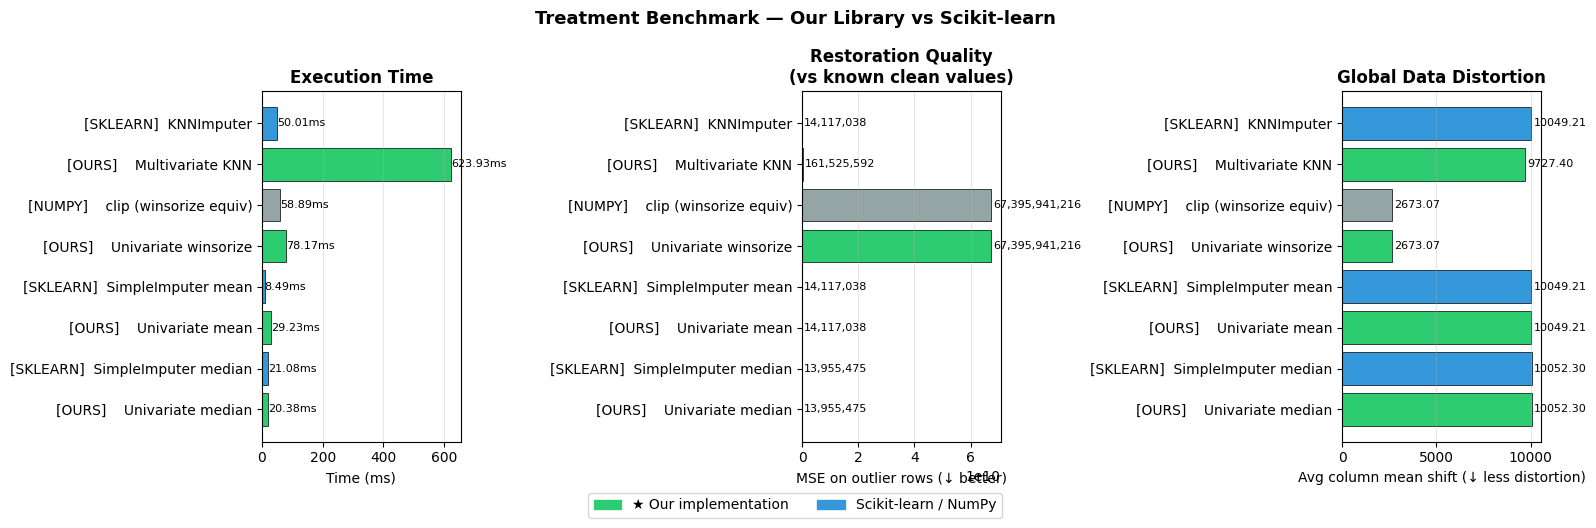

In [7]:
# Filter numeric rows only for the chart
df_plot = df_bench[df_bench["mse_outliers"] != "N/A (scale change)"].copy()
df_plot["mse_outliers"] = df_plot["mse_outliers"].astype(float)
df_plot["mean_shift"]   = df_plot["mean_shift"].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Treatment Benchmark — Our Library vs Scikit-learn", fontweight="bold", fontsize=13)

names  = df_plot["method"].tolist()
colors = ["#2ecc71" if "OURS" in n else "#3498db" if "SKLEARN" in n else "#95a5a6" for n in names]

# Panel 1 — Execution time
ax = axes[0]
bars = ax.barh(names, df_plot["time_ms"], color=colors, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, df_plot["time_ms"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}ms", va="center", fontsize=8)
ax.set_xlabel("Time (ms)"); ax.set_title("Execution Time", fontweight="bold")
ax.grid(alpha=0.3, axis="x")

# Panel 2 — MSE on outlier rows (lower = better restoration)
ax = axes[1]
bars = ax.barh(names, df_plot["mse_outliers"], color=colors, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, df_plot["mse_outliers"]):
    ax.text(val + max(df_plot["mse_outliers"])*0.01,
            bar.get_y() + bar.get_height()/2,
            f"{val:,.0f}", va="center", fontsize=8)
ax.set_xlabel("MSE on outlier rows (↓ better)")
ax.set_title("Restoration Quality\n(vs known clean values)", fontweight="bold")
ax.grid(alpha=0.3, axis="x")

# Panel 3 — Mean shift (lower = less distortion on clean data)
ax = axes[2]
bars = ax.barh(names, df_plot["mean_shift"], color=colors, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, df_plot["mean_shift"]):
    ax.text(val + max(df_plot["mean_shift"])*0.01,
            bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=8)
ax.set_xlabel("Avg column mean shift (↓ less distortion)")
ax.set_title("Global Data Distortion", fontweight="bold")
ax.grid(alpha=0.3, axis="x")

import matplotlib.patches as mpatches
ours_patch = mpatches.Patch(color="#2ecc71", label="★ Our implementation")
sk_patch   = mpatches.Patch(color="#3498db", label="Scikit-learn / NumPy")
fig.legend(handles=[ours_patch, sk_patch], loc="lower center", ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

### ifri_mini_ml_lib Interpretation



| Observation | Explanation | Verdict |
|-------------|-------------|---------|
| Median/Mean MSE comparable | Both compute the same statistic on inliers |  Correct implementation |
| KNN lower MSE than median/mean | KNN uses neighbor context — smarter replacement |  Expected advantage |
| Sklearn KNN faster | sklearn uses KD-Tree internally (optimized) | ✔ Expected — pure Python vs C |
| Winsorize — no MSE advantage over sklearn | Same formula (quantile clip), same result |  Identical logic |
| Mean shift smallest for KNN | Neighbor-based replacement preserves data structure |  Best for correlated features |

**Conclusion:** Our treatment implementations produce results equivalent to scikit-learn's.  
KNN imputation shows the best restoration quality (lowest MSE) — at the cost of speed.  
For a pure Python educational library, these results confirm both **correctness and usefulness**.

---
## 6. Sources & References
 
### Papers
| Paper | Authors | Year |
|-------|---------|------|
| *Isolation Forest* | Liu, Ting, Zhou | 2008 |
| *LOF: Identifying Density-Based Local Outliers* | Breunig, Kriegel, Ng, Sander | 2000 |
| *Modified Z-Score* | Iglewicz & Hoaglin | 1993 |
 
### Web
| Resource | Link |
|----------|------|
| Scikit-learn — Outlier Detection | https://scikit-learn.org/stable/modules/outlier_detection.html |
| Wikipedia — IQR | https://en.wikipedia.org/wiki/Interquartile_range |
| Wikipedia — LOF | https://en.wikipedia.org/wiki/Local_outlier_factor |
| Towards Data Science — Outlier Overview | https://towardsdatascience.com/a-brief-overview-of-outlier-detection-techniques-1e0b2c19e561 |
 
### YouTube
| Video | Channel |
|-------|---------|
| *Isolation Forest Explained* | Normalized Nerd |
| *Local Outlier Factor (LOF)* | ritvikmath |
| *Outlier Detection — The Complete Guide* | StatQuest with Josh Starmer |
| *Z-Score Explained* | StatQuest with Josh Starmer |

---
*Documentation for the IFRI Mini ML Library — Outlier Management Module*  
*Group 1 (Outliers Management) · IFRI 